# GRU Model Evaluation

Loads a trained GRU model and evaluates it on the top-30 Missouri Basin sites.
Produces per-site MAE/flood-quantile accuracy, a prediction plot, persistence baseline comparison, and SHAP feature importance.

In [1]:
import os
import numpy as np
import polars as pl
import tensorflow as tf
import sys
from pathlib import Path

repo_root = Path().resolve().parents[3]
sys.path.insert(0, str(repo_root))

from src.preprocessing.preprocessing import processor
from src.models.gru import GRUModel
from src.utils.helpers import create_sequences

In [2]:
STATIC_FEATURES = [
    "longitude", "latitude", "DRAIN_SQKM", "artificial_path_pct",
    "wb5100_ann_mm", "snw_pc_syr", "snow_ice_nlcd06", "barren_nlcd06",
    "mains100_plant", "hga", "hgc", "bulk_density_avg", "elev_max_m", "aspect_deg"
]

DYNAMIC_FEATURES = [
    "streamflow_cfs_mean", "streamflow_cfs_max", "streamflow_cfs_min",
    "gage_height_ft_mean",
    "precipitation_mm",
    "temperature_c",
    "potential_evaporation_mm",
    "specific_humidity_kgkg",
    "shortwave_radiation_wm2",
    "longwave_radiation_wm2",
    "wind_speed_ms",
    "surface_pressure_pa",
    "cape_jkg",
    "convective_precip_fraction",
]

WINDOW_SIZE = 72

config = {
    "input_cols": DYNAMIC_FEATURES + STATIC_FEATURES,
    "static_cols": STATIC_FEATURES,
    "target": "streamflow_cfs_target_24h",
    "train_split": 0.8,
    "val_split": 0.9,
    "file_path": "flood-dataset-top30",
    "file_name": "flood_model_top30",
    "table": "wandb.flood_model_top30",
    "lag_window": 1,
    "frequency": "hourly",
    "split_time_days": 30,
    "site_scaling": False,
}

## Config

**Windowing strategy:** `lag_window=1` disables the preprocessor's built-in lag expansion; all sequence windowing is handled by `create_sequences(WINDOW_SIZE=72)` below, which creates one 72-timestep window per prediction target.

**`split_time_days=30`**: instead of a single chronological train/val/test cut, the data is split in rolling 30-day chunks. Each chunk contributes train/val/test rows proportionally. This reduces temporal leakage and gives the model exposure to seasonal variation in all three splits.

In [3]:
pcr = processor(config)
pcr.pull_wandb()
print(pcr.df["site_id"].unique())
print(pcr.df.shape)
train_X, val_X, test_X, train_y, val_y, test_y = pcr.return_outputs()
X_test, y_test, test_site_ids = create_sequences(test_X, test_y, WINDOW_SIZE)
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\sacha\_netrc.
wandb: Downloading large artifact 'flood-dataset-top30:latest', 145.19MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.5 (281.4MB/s)


Starting preprocessing: 4,818,417 rows, 31 columns
After lag null removal: 3,412,815 rows, 28 features
Splitting by time...
Train: 2,730,278 | Val: 341,318 | Test: 341,219
Scaling features and targets...
Scaling complete.
shape: (37,)
Series: 'site_id' [str]
[
	"06036650"
	"06449000"
	"06799100"
	"06921590"
	"06093200"
	…
	"06892000"
	"06188000"
	"06895000"
	"06061500"
	"06446700"
]
(4818417, 31)
X_test shape: (338699, 72, 28)
y_test shape: (338699,)


In [4]:
_tmp = GRUModel()
asymmetric_mse = _tmp._loss()

model = GRUModel.load_model(
    "gru_model.keras",
    custom_objects={"asymmetric_mse": asymmetric_mse}
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 72, 32)         │         5,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 72, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 16)             │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,517 (111.40 KB)

 Trainable params: 9,505 (37.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 19,012 (74.27 KB)

## Load Model

`load_model` needs `asymmetric_mse` in `custom_objects` because Keras can't deserialize a custom loss by name alone. We instantiate a throwaway `GRUModel()` just to call `_loss()` and get the function reference — no weights are loaded into it.

In [5]:
model.evaluate(X_test, y_test)

Test mse: 0.3217  |  MAE (scaled): 0.1610


In [6]:
from src.postprocessing.postprocessing import PostProcessor

pp = PostProcessor(
    model=model,
    X_test=X_test,
    y_test=y_test,
    site_ids=test_site_ids,
    target_scaler=pcr.target_scaler,
    feature_names=DYNAMIC_FEATURES + STATIC_FEATURES,
)

c:\Users\sacha\RiceLocal\Capstone\Coding\Flood-Forecasting\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


10585/10585 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step
Overall test mse: 0.3217  |  MAE (scaled): 0.1610

Site 06036650:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test             2029.4 CFS       1957.5 CFS    373.4 CFS


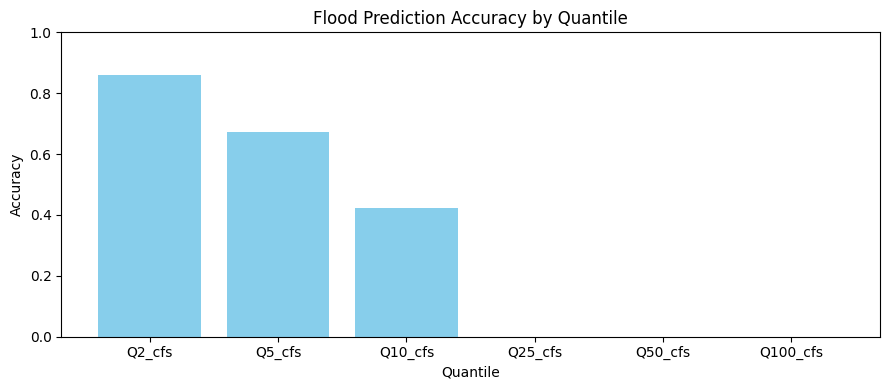


Site 06061500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               54.8 CFS        133.0 CFS     85.4 CFS


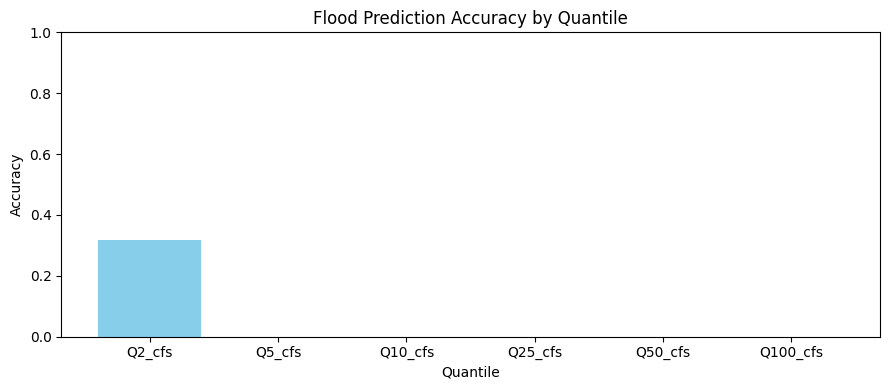


Site 06093200:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              202.0 CFS        198.5 CFS     64.7 CFS


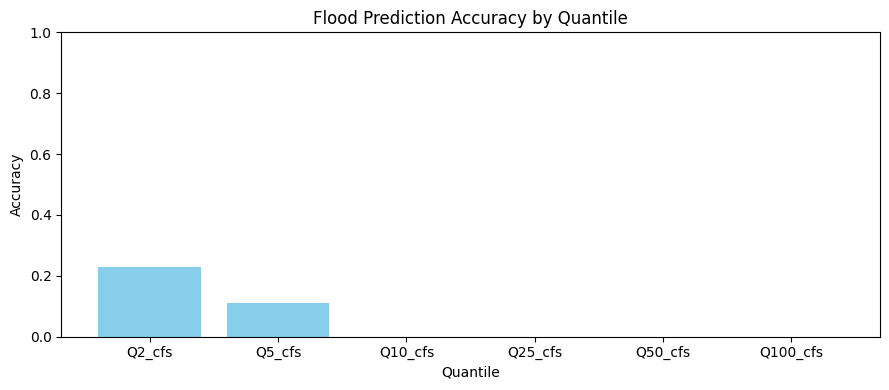


Site 06188000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test             1434.5 CFS       1425.7 CFS    403.1 CFS


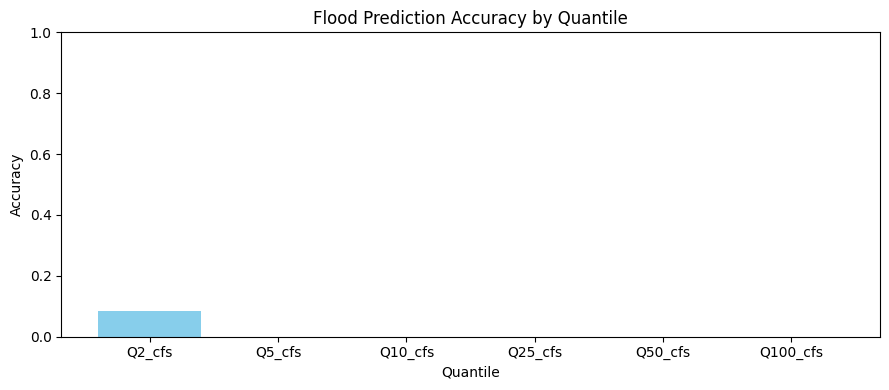


Site 06207500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test             1143.6 CFS       1029.6 CFS    285.5 CFS


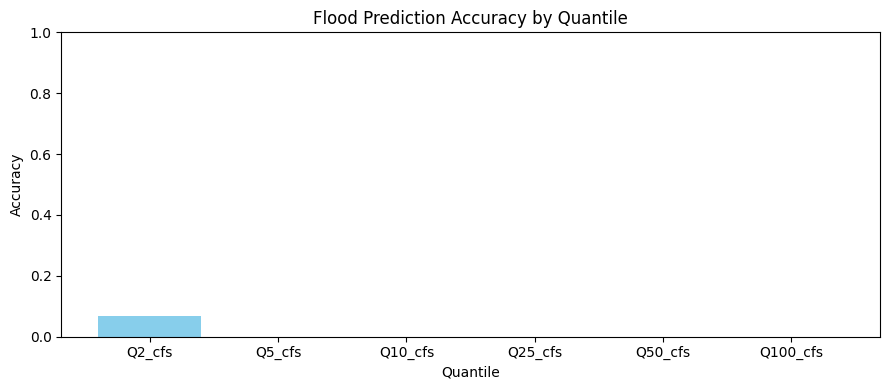


Site 06211000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              104.2 CFS        138.1 CFS     55.7 CFS


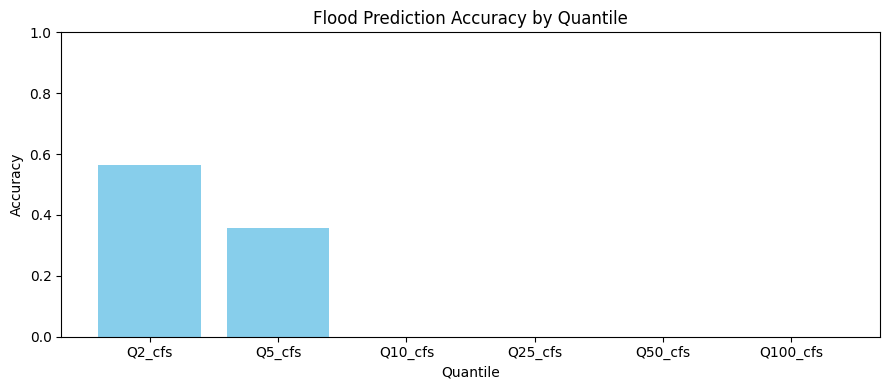


Site 06308500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              539.0 CFS        535.1 CFS    181.3 CFS


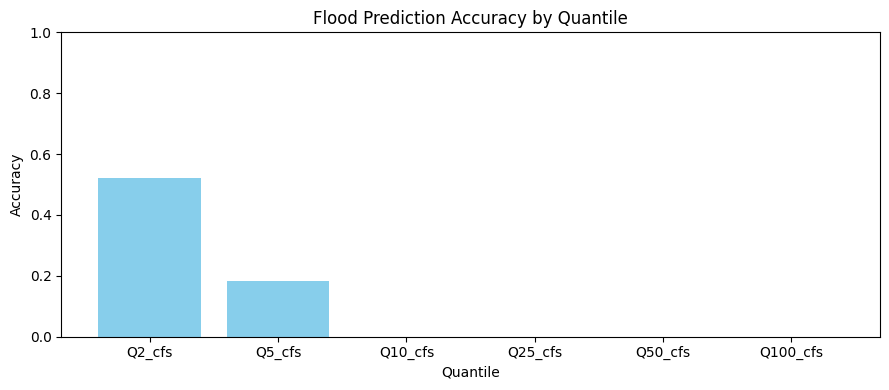


Site 06440200:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               23.4 CFS         56.4 CFS     56.6 CFS


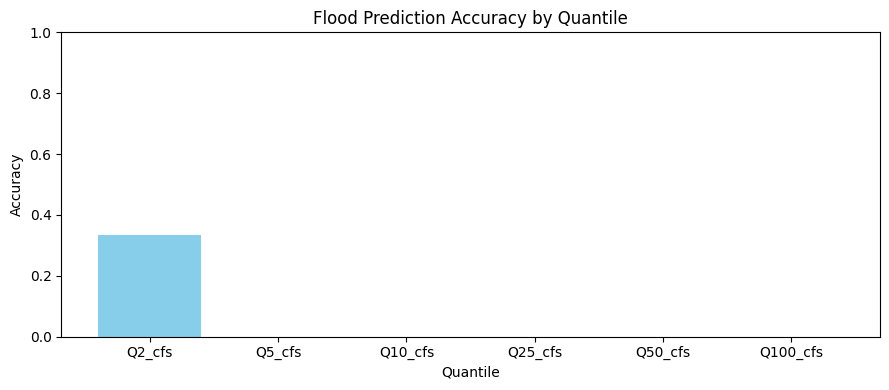


Site 06446700:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               27.1 CFS        105.8 CFS     83.8 CFS


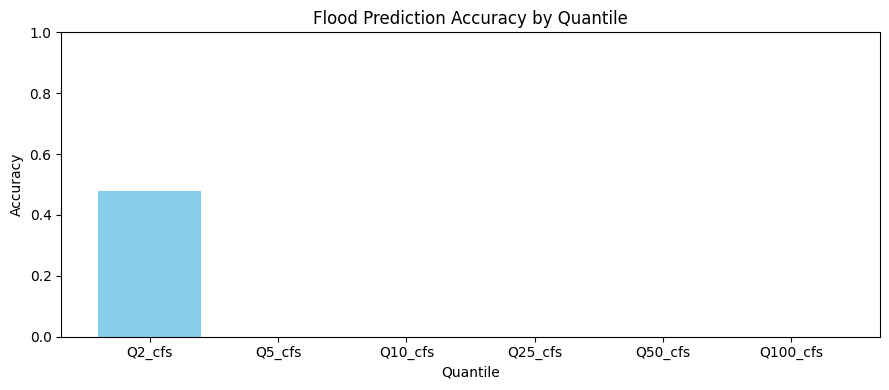


Site 06447500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               36.2 CFS         87.4 CFS     58.4 CFS


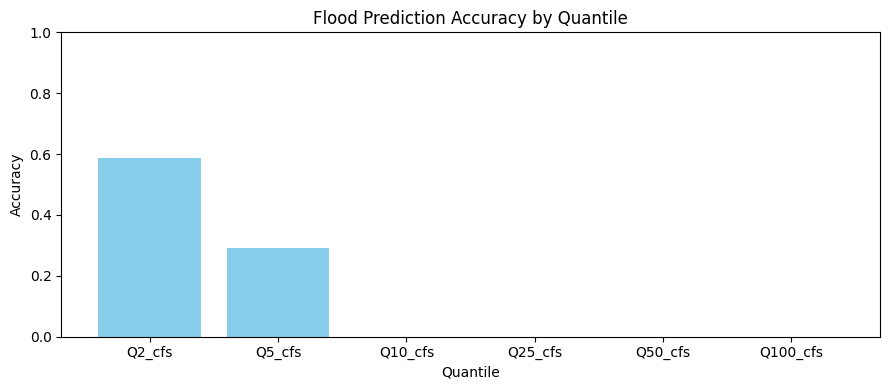


Site 06449000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               34.7 CFS         90.8 CFS     56.6 CFS


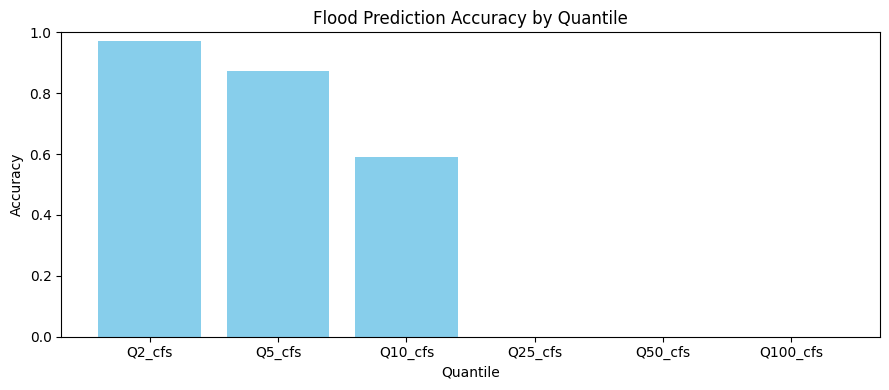


Site 06450500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              243.2 CFS        260.3 CFS     77.8 CFS


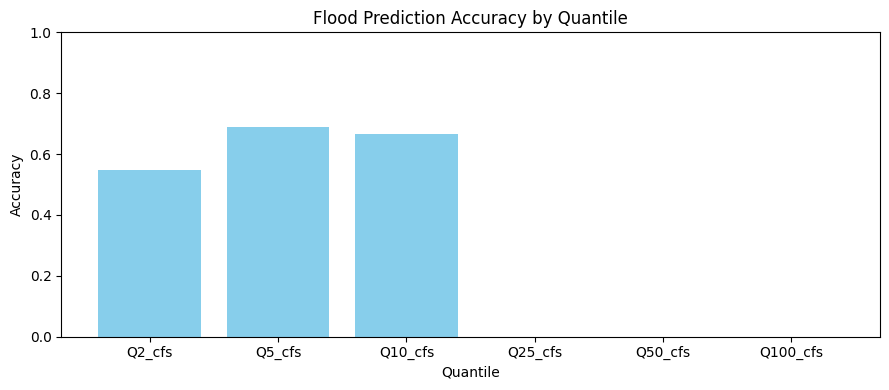


Site 06464100:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               66.6 CFS        103.7 CFS     53.1 CFS


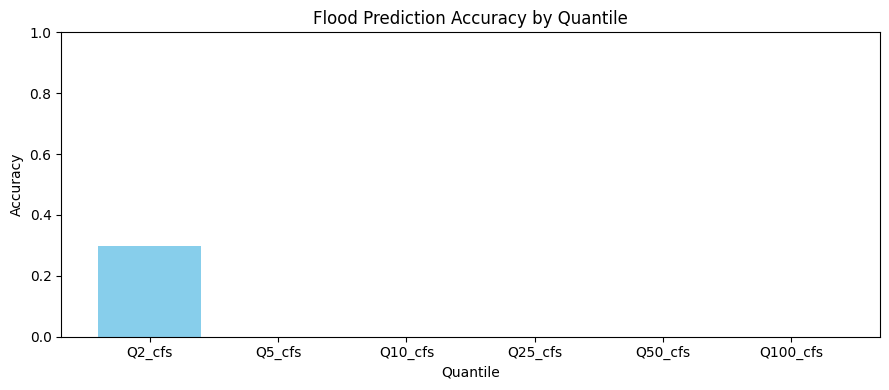


Site 06465700:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              179.7 CFS        213.7 CFS     78.5 CFS


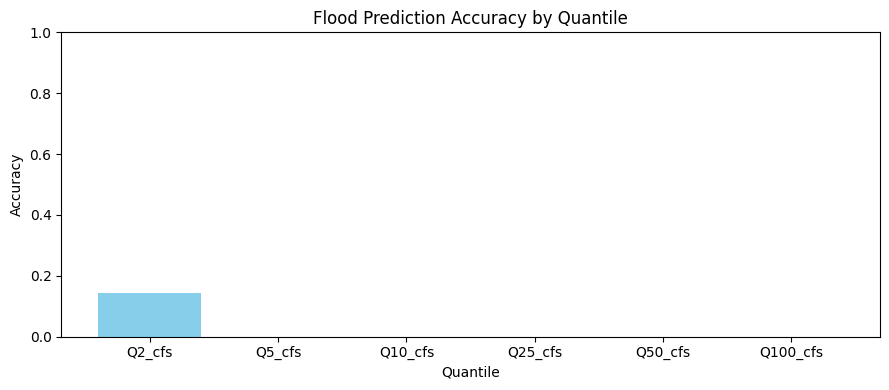


Site 06700000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              200.8 CFS        222.3 CFS     72.9 CFS


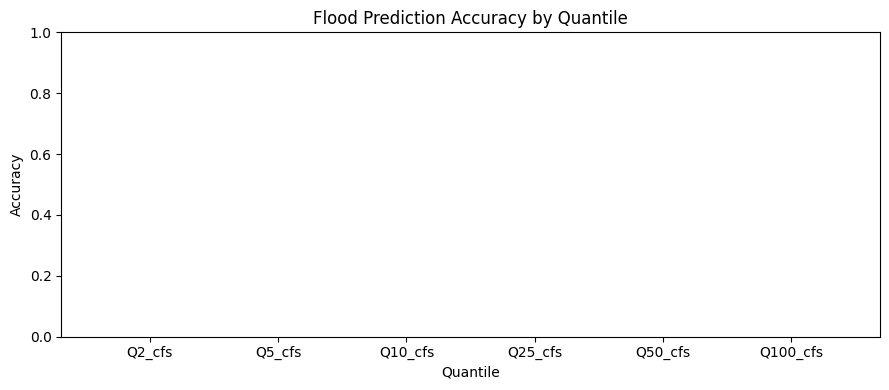


Site 06710385:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               42.7 CFS        149.2 CFS    107.3 CFS


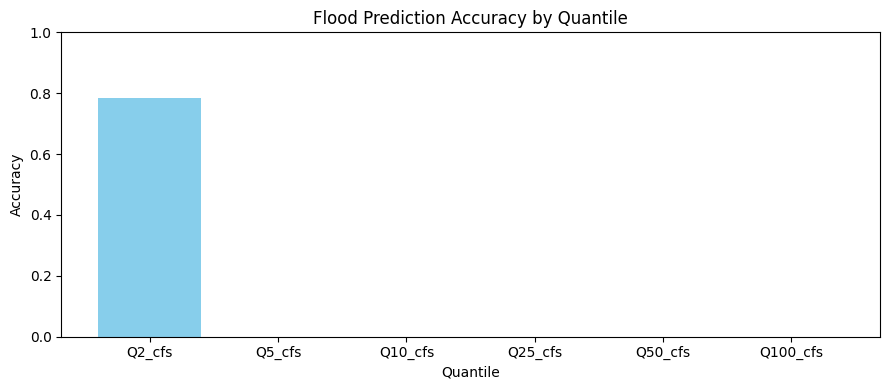


Site 06784000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              235.6 CFS        236.7 CFS     71.1 CFS


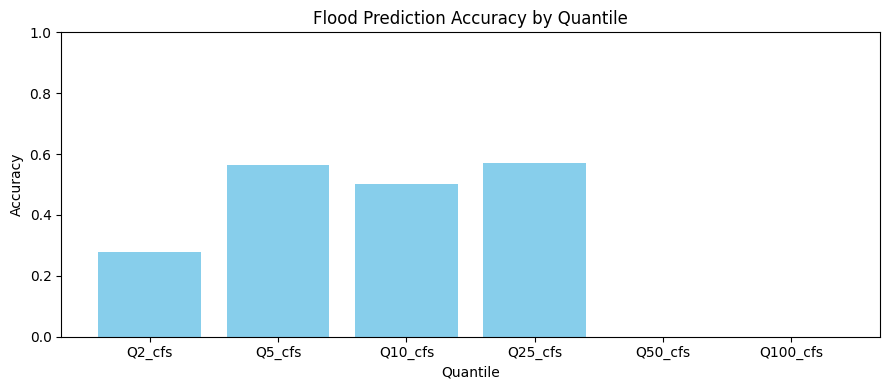


Site 06793000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test             1162.3 CFS       1288.4 CFS    659.4 CFS


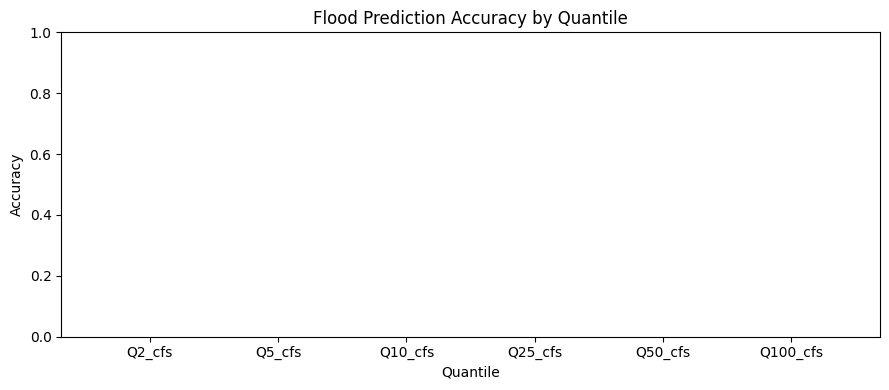


Site 06799100:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              201.2 CFS        253.5 CFS    110.8 CFS


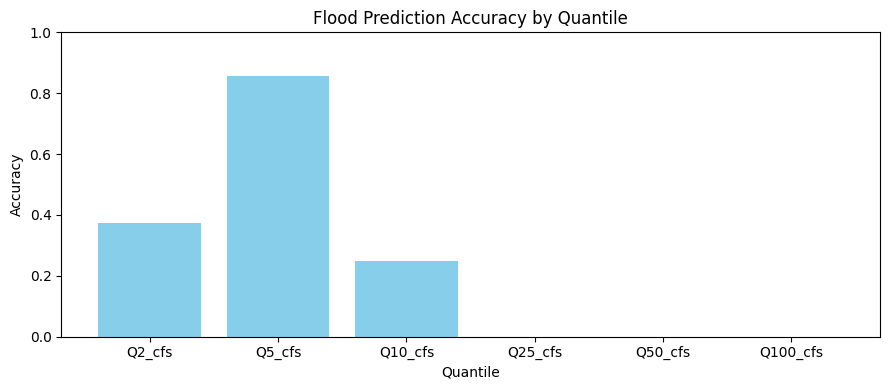


Site 06799315:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test             1190.1 CFS       1147.2 CFS    296.3 CFS


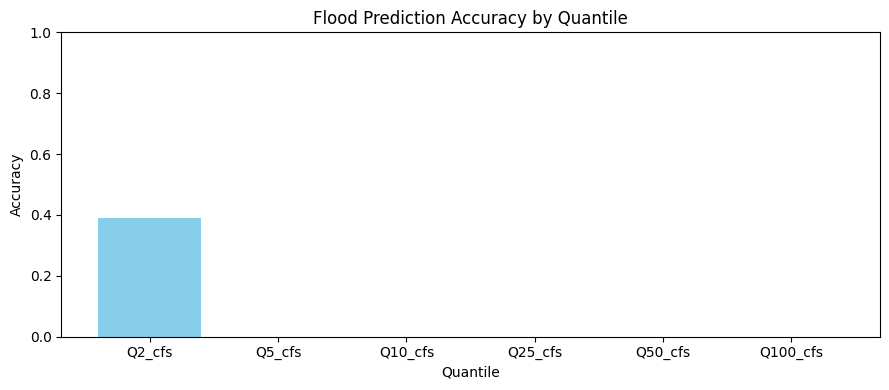


Site 06803495:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              250.8 CFS        268.5 CFS    185.7 CFS


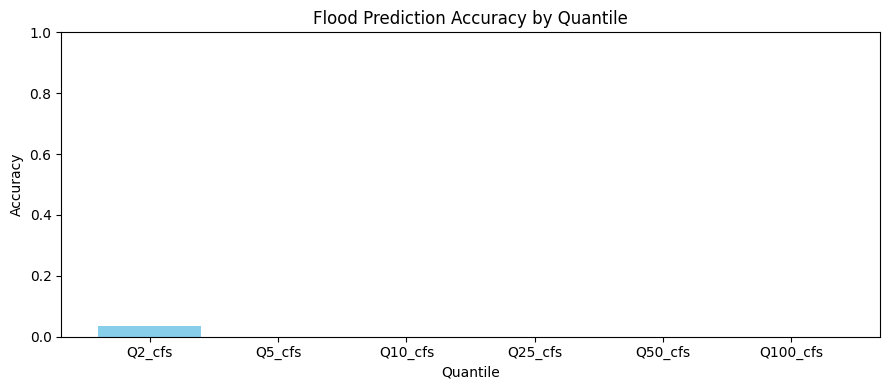


Site 06803500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              272.5 CFS        288.6 CFS    177.9 CFS


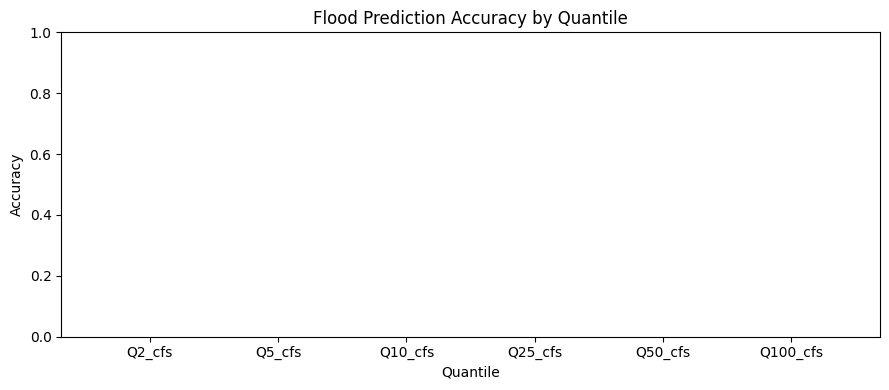


Site 06820500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test             1379.4 CFS       1348.1 CFS    809.8 CFS


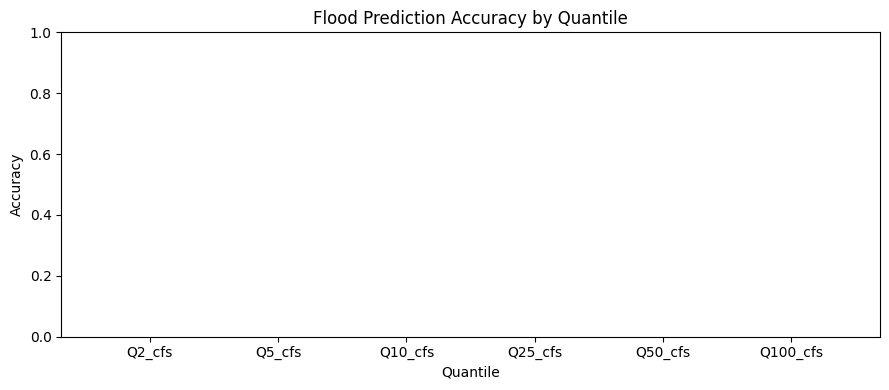


Site 06821500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test                2.4 CFS         79.0 CFS     76.6 CFS


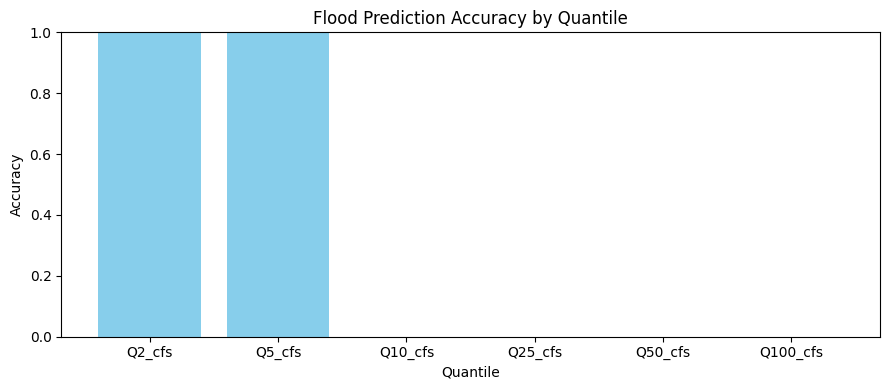


Site 06834000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               20.6 CFS         69.2 CFS     49.7 CFS


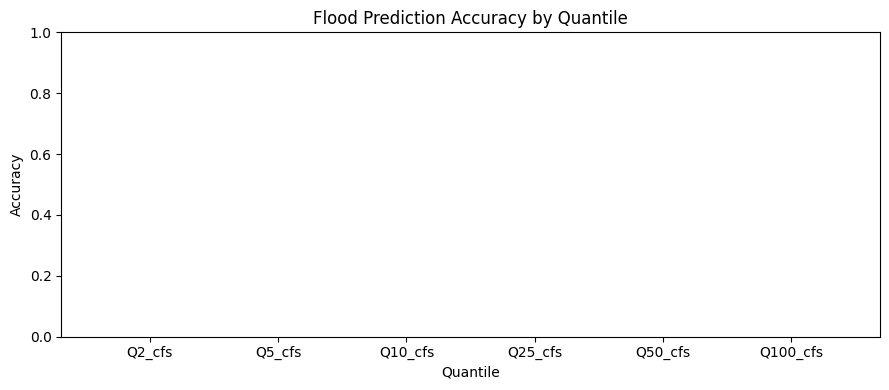


Site 06838000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               12.7 CFS         64.3 CFS     54.8 CFS


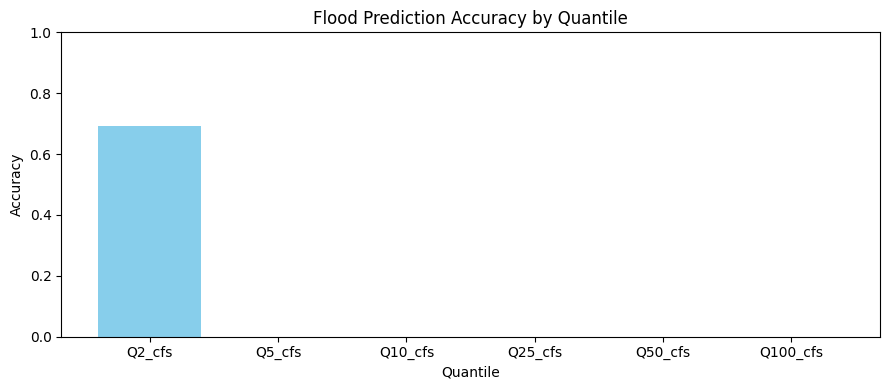


Site 06869950:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               38.8 CFS         85.3 CFS     81.1 CFS


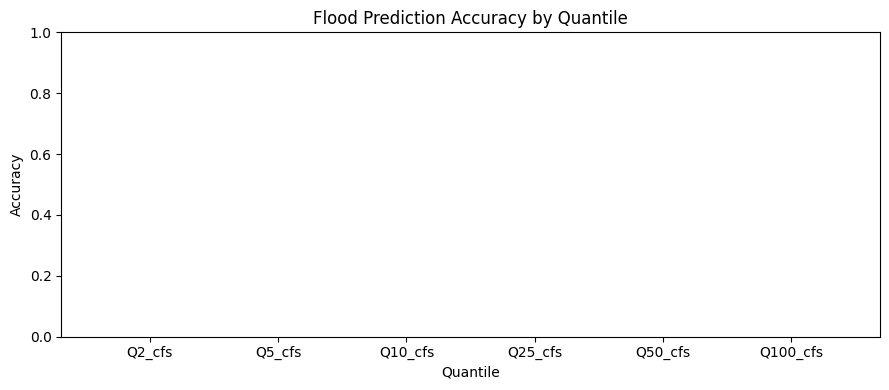


Site 06881000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              447.5 CFS        471.3 CFS    252.0 CFS


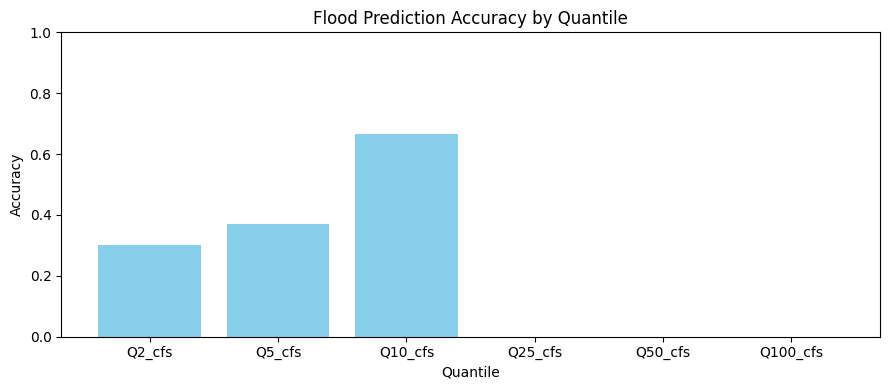


Site 06895000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              158.6 CFS        188.4 CFS    189.8 CFS


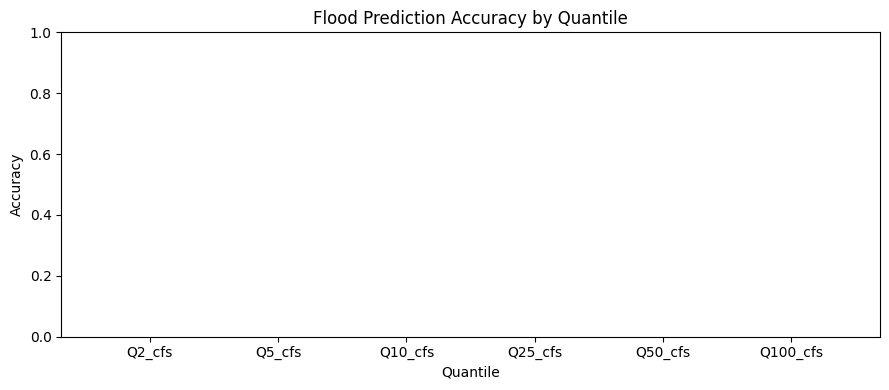


Site 06909500:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               86.4 CFS         89.4 CFS    113.5 CFS


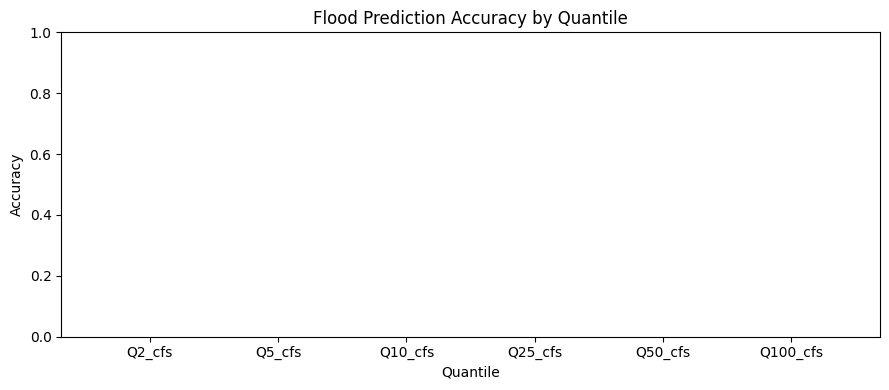


Site 06917000:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              308.6 CFS        296.4 CFS    305.1 CFS


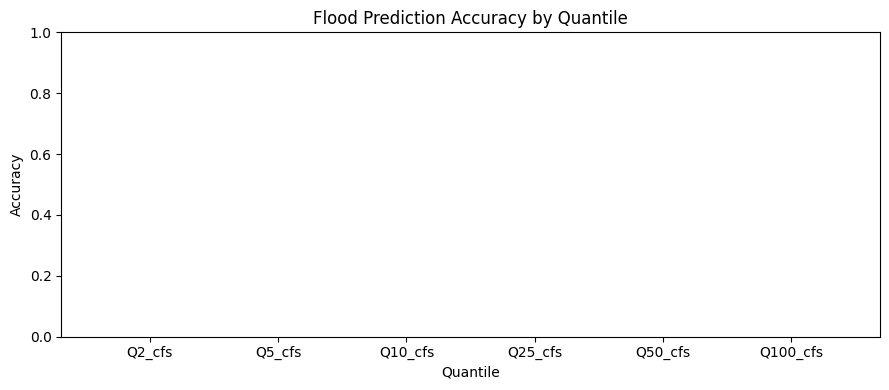


Site 06917060:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              481.3 CFS        497.7 CFS    364.0 CFS


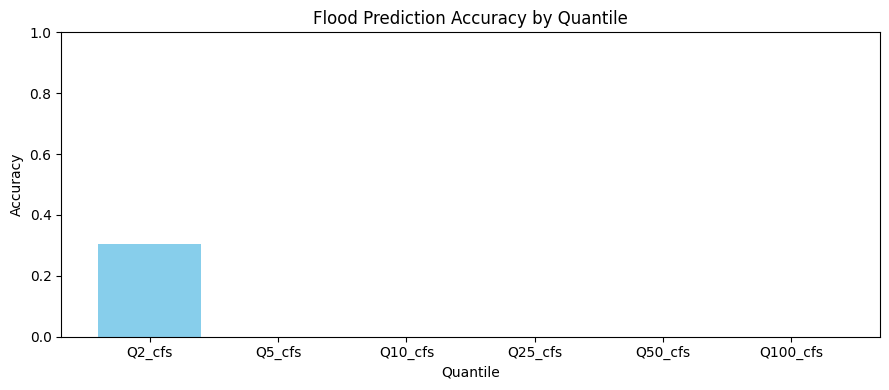


Site 06921590:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test              297.0 CFS        324.1 CFS    340.7 CFS


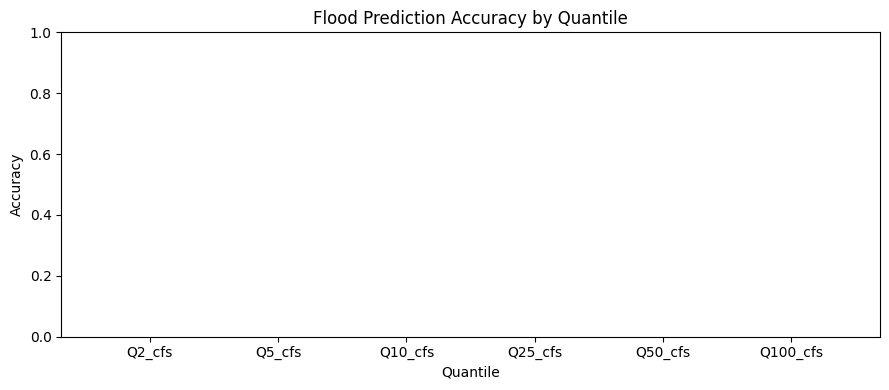


Site 06935755:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test                4.1 CFS         47.7 CFS     48.3 CFS


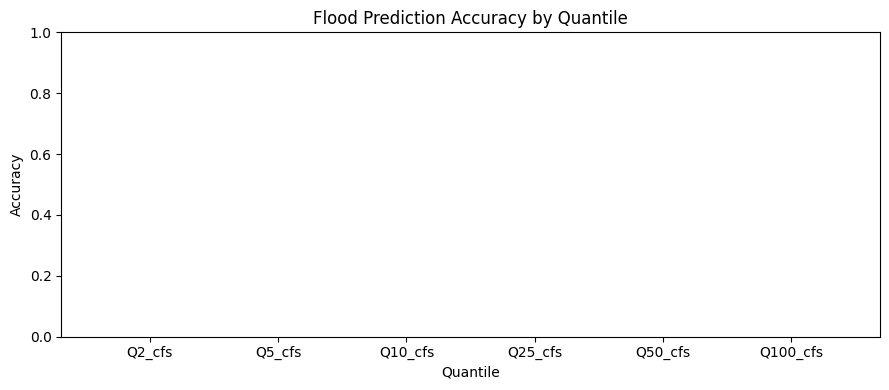


Site 06935955:
  Split          Actual Mean  Predicted Mean          MAE
  ------------------------------------------------------
  Test               20.5 CFS         75.8 CFS     76.6 CFS


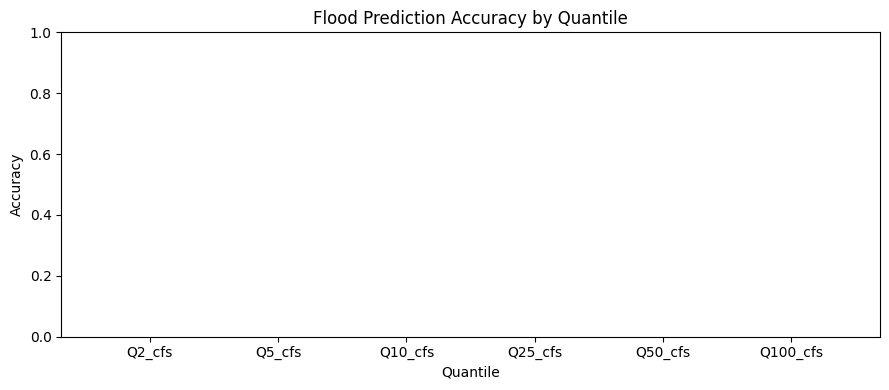

In [7]:
pp.evaluate()

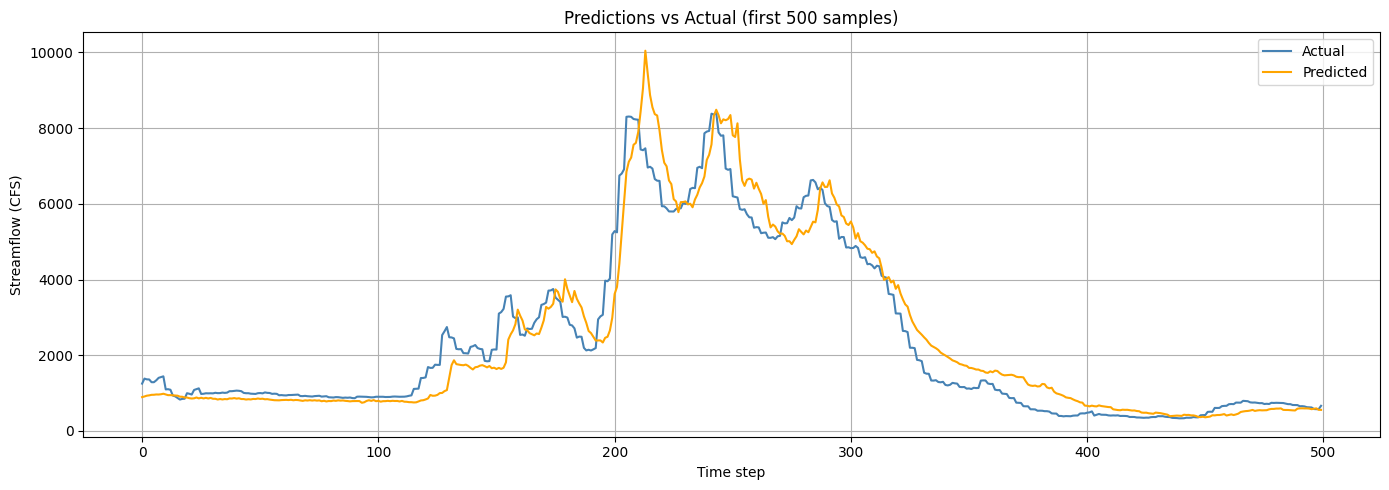

In [8]:
pp.plot_results()

In [9]:
pp.persistence_baseline()

Model                   MAE (scaled)   RMSE (scaled)        NSE
--------------------------------------------------------------
Persistence                   0.0968          0.5559     0.6955
Model                         0.1610          0.5672     0.6830


Subsampling X_test from 338699 to 300 samples for SHAP...
Computing SHAP values via KernelSHAP (nsamples=200)...


 34%|███▍      | 103/300 [03:34<06:59,  2.13s/it]c:\Users\sacha\RiceLocal\Capstone\Coding\Flood-Forecasting\.venv\Lib\site-packages\shap\explainers\_kernel.py:765: UserWarning: Linear regression equation is singular, a least squares solutions is used instead.
To avoid this situation and get a regular matrix do one of the following:
1) turn up the number of samples,
2) turn up the L1 regularization with num_features(N) where N is less than the number of samples,
3) group features together to reduce the number of inputs that need to be explained.
  warnings.warn(
 75%|███████▌  | 225/300 [07:56<02:40,  2.15s/it]c:\Users\sacha\RiceLocal\Capstone\Coding\Flood-Forecasting\.venv\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 3 iterations, i.e. alpha=5.386e-02, with an active set of 3 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.


Done.


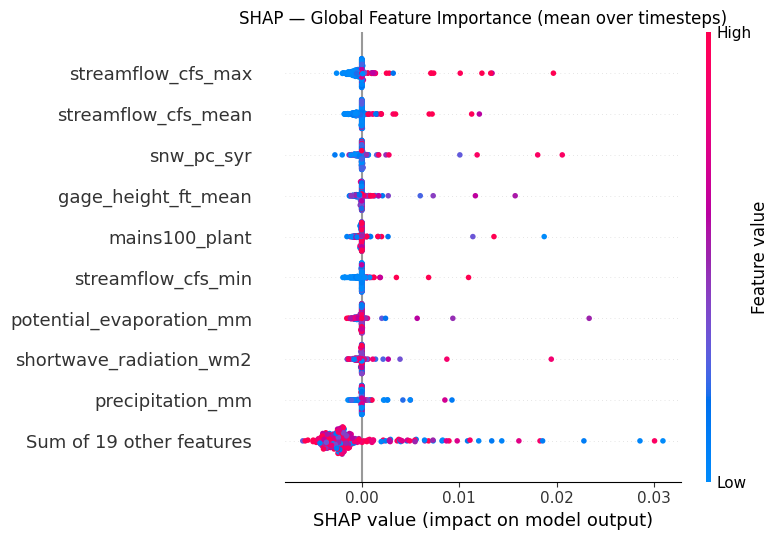

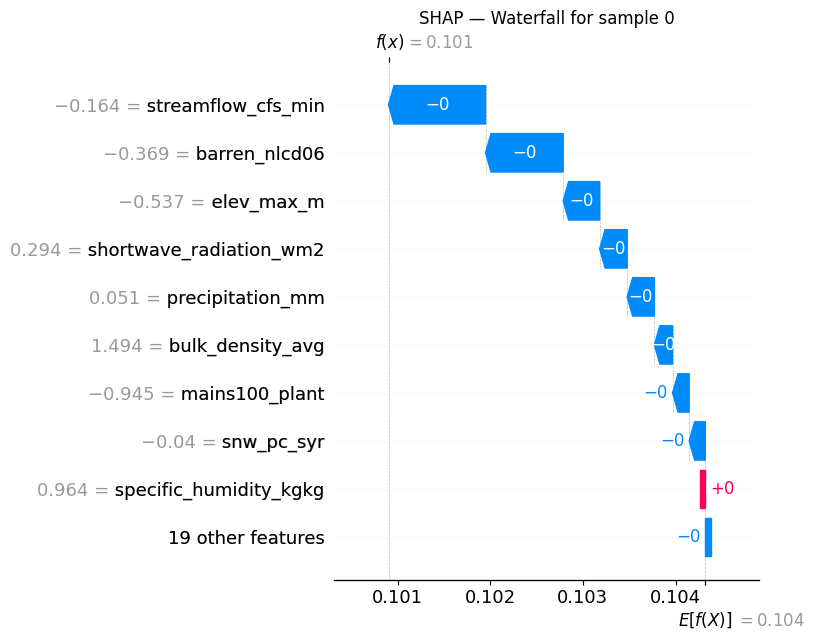

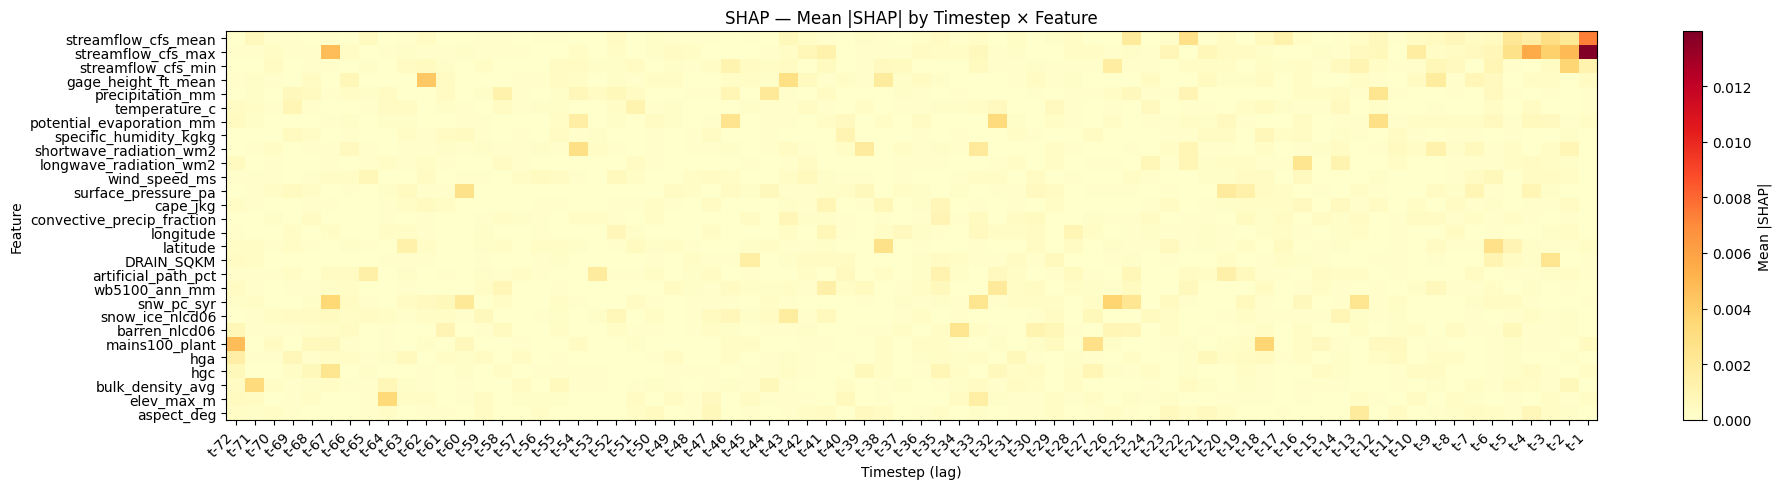

In [10]:
pp.compute_shap()